<div style="text-align: center; padding-top: 12%;">

# Intro to Least Squares and Gradient Descent

## DATA 301 @ WM

<figure class="no-fragment">
<center>
<a href="https://github.com/yanhai-xiong/DATA301-AML/blob/main/Module%203%20-%20Supervised%20Learning%20-%20Regression%20and%20Classification%20Problems/Section%201.1%20-%20Intro%20to%20Least%20Squares%20and%20Gradient%20Descent.ipynb" target="_blank">
    <img class="no-fragment"
         src="https://brand.github.com/_next/static/media/logo-03.cc5e5332.png"
         width="80px"/>
</a>
</center>
</figure>
</div>

## <font color='navy' size=6.5> An Astronomy Problem and The Law of Probable Errors

The story began when an italian astonomer, Giuseppe Piazzi, discovered a new object in our solar system, the dwarf planet (asteroid) Ceres:

https://www.jpl.nasa.gov/news/ceres-keeping-well-guarded-secrets-for-215-years

A german mathematician, Carl Friedrich Gauss, helped relocate the position of Ceres and confirmed the discovery.

"... *for it is now clearly shown that the orbit of a heavenly body may be determined quite nearly from good observations embracing only a few days; and this without any hypothetical assumption*." - Carl Friedrich Gauss

Gauss proposed the *law of probable errors:*

1. Small errors are more likely than large errors;
2. The likelihood of errors of the same magnitude but different signs, such as  x and -x, are equal (the distribution is symmetrical);
3. When several measurements are taken of the same quantity, the average (arithmetic mean) is the most likely value.


References:

- https://www.actuaries.asn.au/research-analysis/gauss-least-squares-and-the-missing-planet

- https://solarsystem.nasa.gov/solar-system/our-solar-system/overview/

## <font color='navy' size=6> **MAIN IDEA:** Mean Squared Errors

From many *independent* imperfect measurements we can easily derive a better one. Here the accent goes on the concept of independence. We say that two events, $A$ and $B$, are independent if

$$\large \text{P}\left(A\cap B\right) = \text{P}\left(A\right)\cdot\text{P}\left(B\right)$$

Observation: While the above statement is correct, it is also deceivingly simple, and it's typically hard to use in practice.

Now, assume we have $n$ independent imperfect, however unbiased, measurements of an object labeled as

$$\large x_1, x_2, \dots x_n$$

and we assume that there is an ideal mesurement $x^*$ and we want to find it. Gauss' idea is to create an objective function that weighs more heavily larger errors. This can be formalized by assuming that we want to compute a value $x$ that minimizes the sum of the squared errors/deviances:

$$\large\text{SSE}\left(x\right)\overset{\Delta}{=} (x-x_1)^2 + (x-x_2)^2 +\dots (x-x_n)^2$$

If we divide by the number of observations, $n$, we get

$$\large\text{MSE}\left(x\right)\overset{\Delta}{=} \frac{(x-x_1)^2 + (x-x_2)^2 +\dots (x-x_n)^2}{n}$$

**Important:** When the number of observations is fixed, $n$ is just a constant.

So, in this case, we want to determine

$$\large \underset{x\,\in\, \mathbb{R}}{\operatorname{argmin}}  \text{SSE}(x)$$

that is to say we want the value of $x$ that yields the minimum of MSE.

To solve the problem, we take the derivative of the MSE with respect to $x$ and set it equal to zero:

$$\large 2(x-x_1) + 2(x-x_2) + \dots 2(x-x_n)=0.$$

When you solve this equation, you get that

$$\large x = \frac{x_1+x_2+\dots x_n}{n}$$

This highlights the idea that the average is the best representative of a sample.













# Motivation Example
How can a machine learn relationships from data?

Suppose we observe that students who study longer tend to earn higher exam scores. Can we use the observed data to learn a model that captures this relationship?

> For example:
Can we find a line that predicts a student's exam score based on the number of hours they study?

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

# Generate sample data
# X: hours studied
X = np.arange(1, 6)

# Y: exam score
# Assume an underlying relationship: score ≈ 45 + 4 * hours studied
# Add random noise to make the data realistic
Y = 45 + 4 * X + np.random.normal(0, 4, len(X))

# Create a DataFrame
data = pd.DataFrame({
    "Study Hours": X,
    "Exam Score": Y
})

In [5]:
data

,Study Hours,Exam Score
0,1,50.986857
1,2,52.446943
2,3,59.590754
3,4,67.092119
4,5,64.063387


## Signal, Noise, and the Regression Goal

Assume the observed outcome is generated by
$ Y = f(X) + \epsilon $

where:
- $f(X)$ the systematic relationship (**signal**) between $X$ and $Y$
- $\epsilon$ random variation (**noise**) that cannot be explained by $X$
- $Y$ the observed outcome, containing both signal and noise

However, we do not know the true function $f(X)$.

**Goal of Regression**
- Given observed data $(X,Y)$, regression attempts to learn a model
$ \hat f(X) \approx f(X) $
that predicts $Y$ as accurately as possible.

> **We cannot eliminate the noise, but we can find a model that minimizes the prediction error.**


## How Do We Decide Which Line Is Better?

There are many possible lines we could use to model the relationship between**study hours** and **exam scores**.

Consider two candidate lines below:

> **Which line better represents the data? How can we decide objectively?**

In [39]:
# Plot the observed data
plt.scatter(X, Y, s=60, label="Observed Data")

# Two candidate prediction lines
Y_line1 = 43 + 4.2 * X
Y_line2 = 52 + 2.5 * X

plt.plot(X, Y_line1, linewidth=2, label="Line 1")
plt.plot(X, Y_line2, linewidth=2, label="Line 2")

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Which Line Better Represents the Data?")
plt.legend()

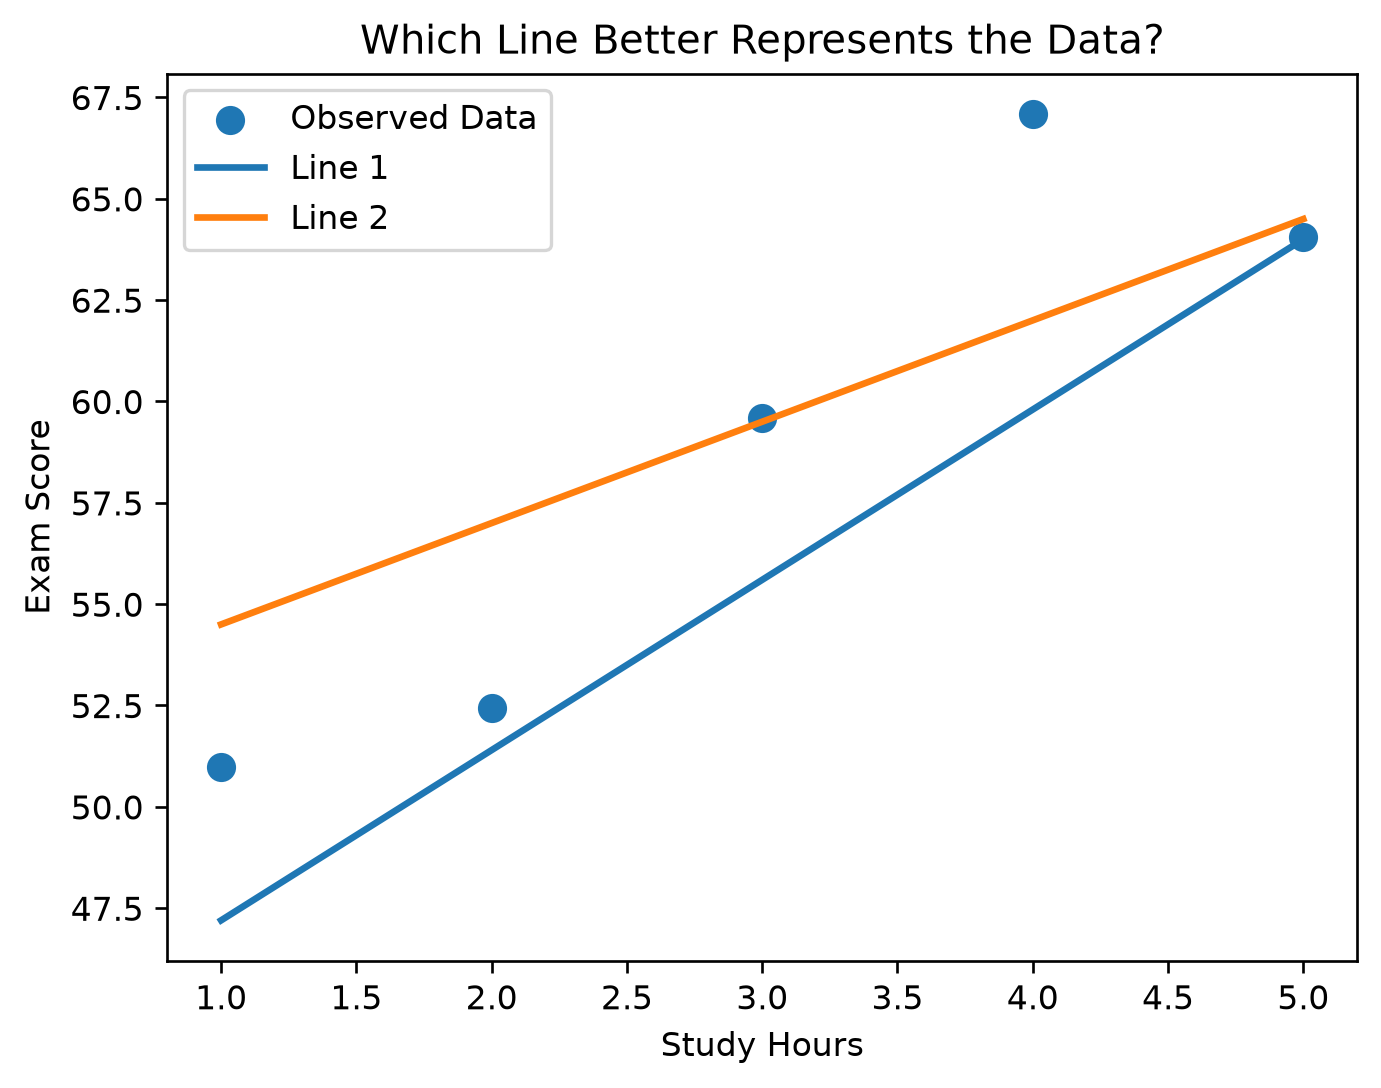

In [39]:
plt.show()

# <font color='navy' size=6pt> Predicting a Continuous Random Variable </font>

## Main Idea
- the output (dependent) variable is continuous and we want to "predict" its value within the range of the input features. 
- there is "noise" which means that for essentially the same input values there may be slightly different values of the output variable or there is "noise" in the measurement of all the variables.  

## **Main Approach**
- We want to estimate the expected value of the dependent variable as a function of the input features. Thus we want to approximate a conditional expectation $\mathbb{E}(Y|\text{input features})$ as a function of the input features such as
$\large \mathbb{E}(Y|X=x) = f(x)$

- We want to determine the simplest form of the function $f$ (principle of parsimony) and we assume that
$\large Y = f(X) + \sigma \epsilon$

where $\epsilon$ is the "noise", in statistical terms, $\epsilon$ is independent and identically distributed, it follows a standard normal distribution and, $\sigma>0$ is generally unknown.

# <font color='navy' size=6pt>Ordinary Least Squares Regression (OLS)</font>

First, we assume the simplest case: data has only one input feature that is continuous.

The main idea of linear regression is the expected value of the output is a linear function of the input variable(s):
$\large \mathbb{E}(Y|X=x)\approx m\cdot x + b$

To determine the line of best fit the goal is to minimize the sum/average of squared residuals (cost function):


$$\large
\min_{m,b} L(m,b) = \frac{1}{N}\min_{m,b} \sum\limits_{i=1}^{N}(y_i-mx_i-b)^2
$$


## How Does the Loss Change with the Model Parameters?

In **Ordinary Least Squares (OLS)**, we want to find the parameters \(m\) and \(b\) that minimize the loss:

$$
L(m,b)=\frac{1}{N}\sum_{i=1}^{N}\left[y_i-(mx_i+b)\right]^2.
$$

Different values of \(m\) and \(b\) produce different prediction lines—and therefore different loss values.

### Let's Start with One Parameter

To make this easier to visualize, suppose we temporarily **fix the intercept \(b\)** and only change the slope \(m\). Then the loss becomes a function of one parameter: $L(m)$.

> <font color='forestgreen'>**Critical Thinking:** How does the loss change as we change \(m\)? Can we use this information to find the value of \(m\) that minimizes the loss?</font>

In [49]:
# Model: Y_hat = wX + b
# Temporarily fix b = 45 and study how the loss changes with w

b = 45

def loss(w):
    Y_hat = w * X + b
    return np.mean((Y - Y_hat)**2)

w_values = np.linspace(0, 8, 200)
loss_values = [loss(w) for w in w_values]
plt.figure(figsize=(4, 3), dpi=100)
plt.plot(w_values, loss_values)

plt.xlabel("w")
plt.ylabel("Loss $L(w)$")
plt.title("How Does the Loss Change with $w$?")
plt.grid(alpha=0.3)

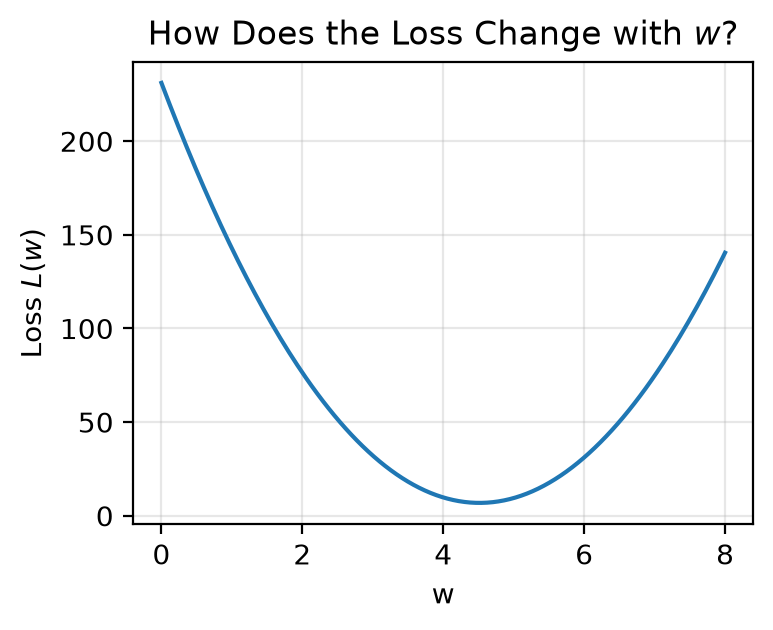

In [49]:
# Loss value of different w with fixed b=45
plt.show()

## How Can We Find the Minimum?

The derivative tells us how the loss changes when we change $m$:

$$
\frac{dL}{dm}
$$
- If $\frac{dL}{dm}>0$, increasing $m$ increases the loss → move $m$ **down**.
- If $\frac{dL}{dm}<0$, increasing $m$ decreases the loss → move $m$ **up**.
- At the minimum, $\frac{dL}{dm}=0$.

This suggests an iterative strategy:

> **Start with an initial value of $m$, determine which direction decreases the loss, take a step in that direction, and repeat.**

This is the key idea behind **gradient descent**.


# <font color='navy' size=6>From One Parameter to Multiple Parameters</font>

Previously, we fixed the intercept \(b\) and examined how the loss changes with the slope \(m\):
$ L(m)$

But in linear regression, we usually need to learn **both** parameters:
$\hat{y}=mx+b.$

Therefore, the loss depends on both \(m\) and \(b\):

$$
L(m,b)=\frac{1}{N}\sum_{i=1}^{N}\left[y_i-(mx_i+b)\right]^2.
$$

Changing either \(m\) or \(b\) changes the prediction line and therefore changes the loss.

> <font color='forestgreen'>**Critical Thinking:** If we can change both \(m\) and \(b\), how do we determine which direction will decrease the loss?</font>


## <font color='navy' size=6>Partial Derivatives: Which Way Should Each Parameter Move?</font>

With one parameter, we used the derivative $\frac{dL}{dm}$
to determine how the loss changes as \(m\) changes.

With two parameters, we use a **partial derivative for each parameter**:
- $\frac{\partial L}{\partial m}\quad\longrightarrow\quad\text{How does the loss change when we change }m?$
- $\frac{\partial L}{\partial b}\quad\longrightarrow\quad\text{How does the loss change when we change }b?$

Together, these partial derivatives tell us how the loss changes with respect to **all model parameters**.


## <font color='navy' size=6>The Gradient</font>

Instead of considering each partial derivative separately, we collect them into a vector called the **gradient**:

$$
\nabla L(m,b)
=
\begin{bmatrix}
\frac{\partial L}{\partial m}\\
\frac{\partial L}{\partial b}
\end{bmatrix}.
$$

The gradient points in the direction of the **steepest increase** in the loss.

Therefore,

$$
-\nabla L(m,b)
$$

points in the direction of the **steepest decrease**.

> To reduce the loss, move the model parameters in the **opposite direction of the gradient**.


## <font color='navy' size=6>Gradient Descent</font>

Starting from initial values of $m$ and $b$, repeatedly move them in the direction that decreases the loss:

$$
m_{\text{new}}
=
m_{\text{old}}
-
\eta\frac{\partial L}{\partial m}
$$

$$
b_{\text{new}}
=
b_{\text{old}}
-
\eta\frac{\partial L}{\partial b}
$$

where $\eta$ is the **learning rate**, which controls the size of each step.

In vector form:

$$
\begin{bmatrix}
m\\
b
\end{bmatrix}_{\text{new}}
=
\begin{bmatrix}
m\\
b
\end{bmatrix}_{\text{old}}
-
\eta\nabla L(m,b).
$$

### Gradient Descent Algorithm

1. Start with initial values of the model parameters.
2. Calculate the predictions and loss.
3. Calculate the gradient.
4. Update the parameters in the negative gradient direction.
5. Repeat until the loss stops decreasing significantly.


## <font color='navy' size=6>Gradient of the OLS Loss</font>

For linear regression, $\hat{y}_i=mx_i+b$
with the MSE loss $L(m,b)=\frac{1}{N}\sum_{i=1}^{N}\left[y_i-(mx_i+b)\right]^2.$

The partial derivative with respect to \(m\) is

$$
\frac{\partial L}{\partial m}
=
-\frac{2}{N}
\sum_{i=1}^{N}
x_i
\left[y_i-(mx_i+b)\right].
$$

The partial derivative with respect to \(b\) is

$$
\frac{\partial L}{\partial b}
=
-\frac{2}{N}
\sum_{i=1}^{N}
\left[y_i-(mx_i+b)\right].
$$

Gradient descent uses these values to determine how to update both parameters.


In [43]:
# Initialize parameters
m = 0.0
b = 0.0

learning_rate = 0.01
n_iterations = 1000
n = len(X)

# Store the training history
m_history = []
b_history = []
loss_history = []

for i in range(n_iterations):

    # 1. Make predictions
    Y_pred = m * X + b

    # 2. Calculate errors
    errors = Y - Y_pred

    # 3. Calculate MSE loss
    loss = np.mean(errors ** 2)

    # Save current position
    m_history.append(m)
    b_history.append(b)
    loss_history.append(loss)

    # 4. Calculate gradient
    dm = -(2 / n) * np.sum(X * errors)
    db = -(2 / n) * np.sum(errors)

    # 5. Update parameters
    m = m - learning_rate * dm
    b = b - learning_rate * db

print(f"Final m = {m:.3f}")
print(f"Final b = {b:.3f}")
print(f"Final loss = {loss_history[-1]:.3f}")

Final m = 4.475
Final b = 45.168
Final loss = 6.781


In [44]:
# Create possible values of m and b
m_values = np.linspace(0, 10, 150)
b_values = np.linspace(0, 60, 150)

M, B = np.meshgrid(m_values, b_values)

# Calculate L(m, b) at every point
L = np.zeros_like(M)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):

        Y_pred = M[i, j] * X + B[i, j]

        L[i, j] = np.mean((Y - Y_pred) ** 2)

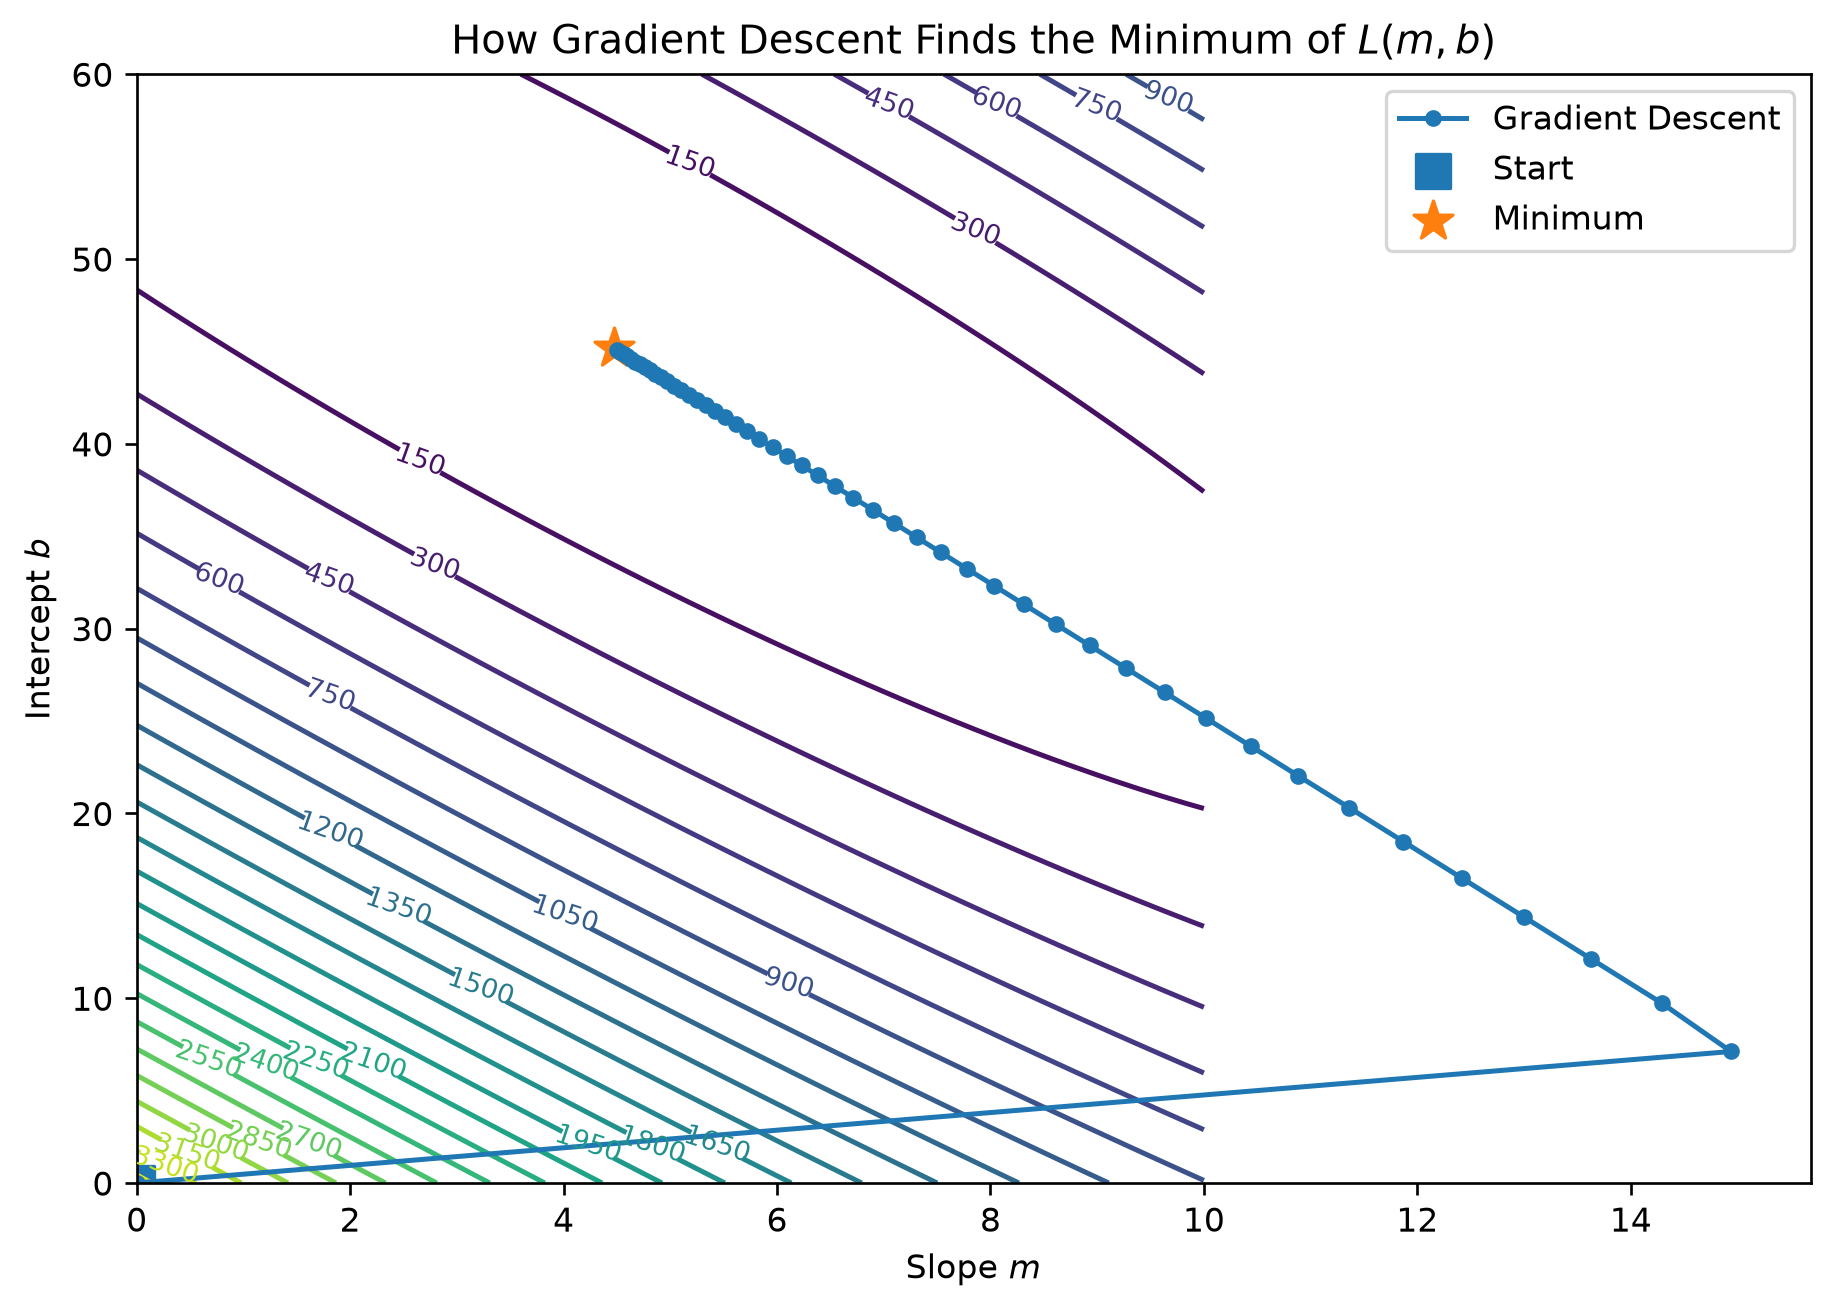

In [45]:
step = 20

plt.figure(figsize=(9, 6))

contours = plt.contour(M, B, L, levels=30)
plt.clabel(contours, inline=True, fontsize=8)

plt.plot(
    m_history[::step],
    b_history[::step],
    "o-",
    markersize=4,
    label="Gradient Descent"
)

plt.scatter(
    m_history[0],
    b_history[0],
    s=100,
    marker="s",
    label="Start"
)

plt.scatter(
    m_history[-1],
    b_history[-1],
    s=150,
    marker="*",
    label="Minimum"
)

plt.xlabel("Slope $m$")
plt.ylabel("Intercept $b$")
plt.title("How Gradient Descent Finds the Minimum of $L(m,b)$")

plt.legend()
plt.show()

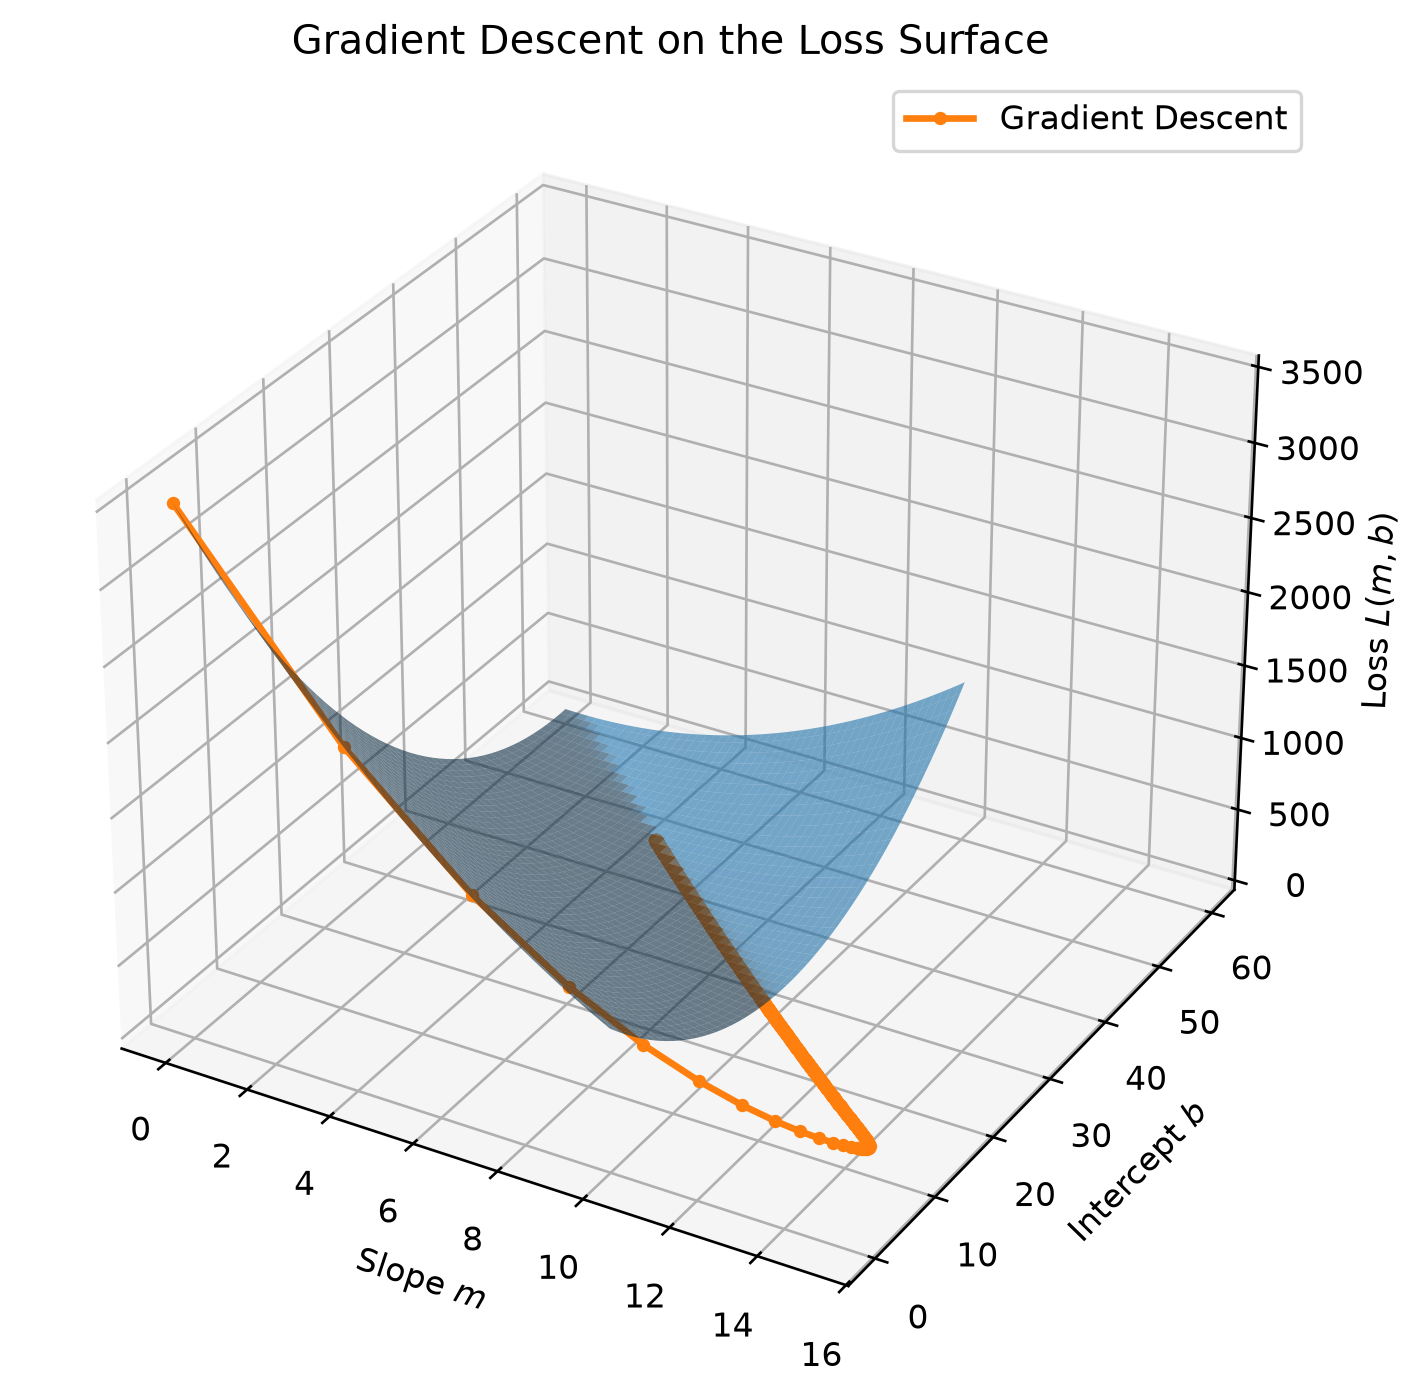

In [46]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

# Loss surface
ax.plot_surface(
    M, B, L,
    alpha=0.6
)

# Gradient descent path
ax.plot(
    m_history,
    b_history,
    loss_history,
    "o-",
    markersize=3,
    linewidth=2,
    label="Gradient Descent"
)

ax.set_xlabel("Slope $m$")
ax.set_ylabel("Intercept $b$")
ax.set_zlabel("Loss $L(m,b)$")

ax.set_title("Gradient Descent on the Loss Surface")

ax.legend()

plt.show()

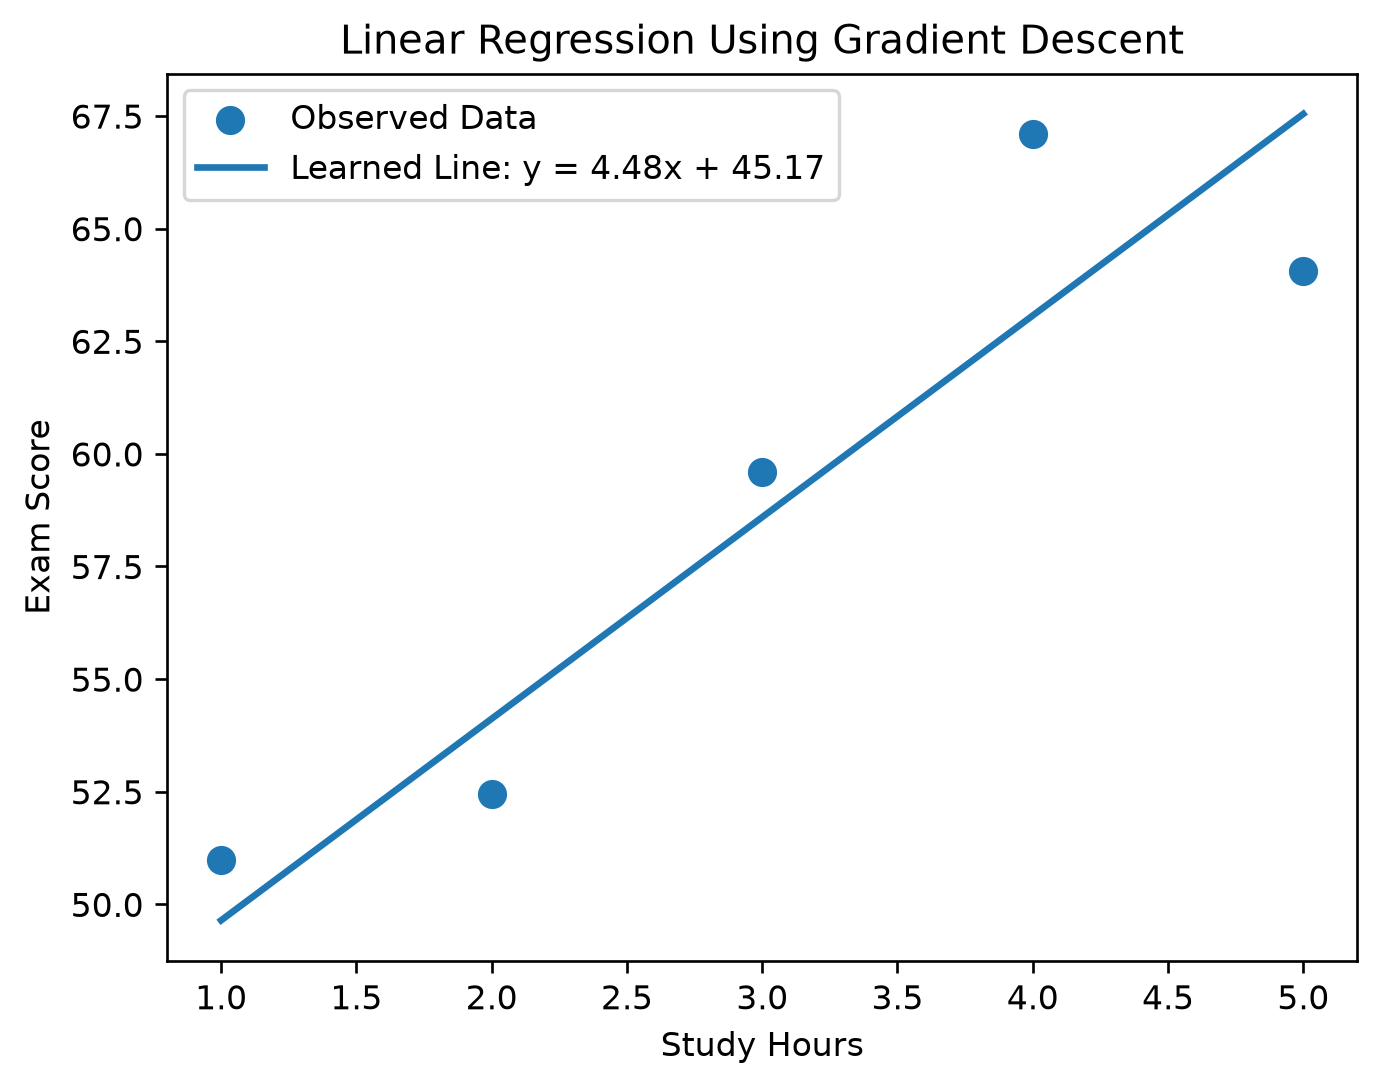

In [47]:
# Predictions using the learned parameters
Y_pred = m * X + b

plt.scatter(X, Y, s=60, label="Observed Data")
plt.plot(X, Y_pred, linewidth=2,
         label=f"Learned Line: y = {m:.2f}x + {b:.2f}")

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Linear Regression Using Gradient Descent")
plt.legend()

plt.show()

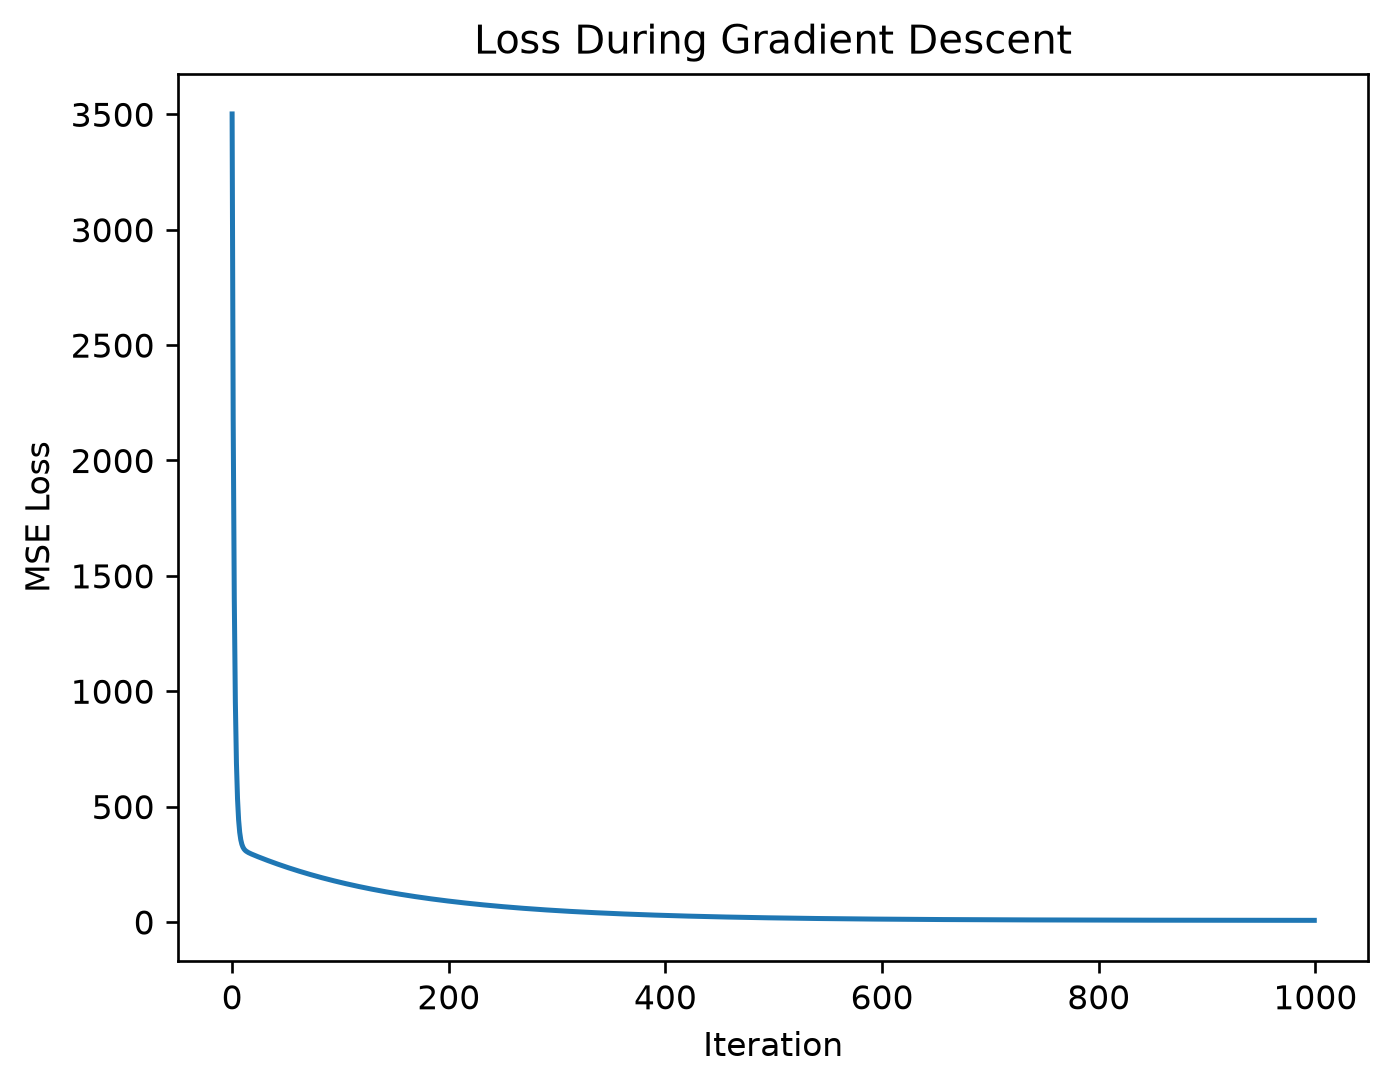

In [48]:
# Plot how the loss changes during training
plt.plot(loss_history)

plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Loss During Gradient Descent")

plt.show()